In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_PATH = "dataset.csv"   # adjust if needed
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
df.head(70)


Shape: (423, 16)


,event_id,organizer_name,category,place,posted_datetime,event_start_datetime,event_end_datetime,price_syp,capacity,attendance,attendance_rate,day_of_week,is_weekend_syria,start_hour,days_before_event_posted,duration_hours
0,E0412,Syrian EDS,Camping,Lattakia,2025-12-04 22:11:00,2025-12-19 14:00:00,2025-12-26 14:00:00,320000,220,195,0.886364,4,1,14,14.659028,168.0
1,E0371,Syrian EDS,Camping,Lattakia,2025-01-26 09:14:00,2025-02-01 20:00:00,2025-02-06 20:00:00,335000,170,127,0.747059,5,1,20,6.448611,120.0
2,E0446,Syrian EDS,Camping,Homs,2024-10-17 22:19:00,2024-11-08 19:00:00,2024-11-12 19:00:00,225000,150,147,0.980000,4,1,19,21.861806,96.0
3,E0130,Syrian EDS,Camping,Lattakia,2025-11-05 20:46:00,2025-11-08 16:30:00,2025-11-11 16:30:00,120000,230,129,0.560870,5,1,16,2.822222,72.0
4,E0194,Syrian EDS,Camping,Lattakia,2024-02-22 09:17:00,2024-03-01 21:30:00,2024-03-03 21:30:00,300000,210,148,0.704762,4,1,21,8.509028,48.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65,E0099,Styria,Comedy,Mazzeh,2025-09-19 05:28:00,2025-09-24 15:30:00,2025-09-24 20:30:00,50000,60,37,0.616667,2,0,15,5.418056,5.0
66,E0159,Styria,Comedy,Kafarsoseh,2024-07-31 06:23:00,2024-09-03 19:30:00,2024-09-03 22:30:00,50000,50,35,0.700000,1,0,19,34.546528,3.0
67,E0072,Styria,Comedy,jesr abiad,2025-05-18 11:21:00,2025-06-20 15:30:00,2025-06-20 20:00:00,50000,60,56,0.933333,4,1,15,33.172917,4.5
68,E0058,Styria,Comedy,Mazraa,2024-02-21 01:57:00,2024-03-04 18:30:00,2024-03-04 23:30:00,50000,50,32,0.640000,0,0,18,12.689583,5.0


In [37]:
df.info()
display(df.describe(include="all").T.head(30))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 423 entries, 0 to 422
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   event_id                  423 non-null    object 
 1   organizer_name            423 non-null    object 
 2   category                  423 non-null    object 
 3   place                     423 non-null    object 
 4   posted_datetime           423 non-null    object 
 5   event_start_datetime      423 non-null    object 
 6   event_end_datetime        423 non-null    object 
 7   price_syp                 423 non-null    int64  
 8   capacity                  423 non-null    int64  
 9   attendance                423 non-null    int64  
 10  attendance_rate           423 non-null    float64
 11  day_of_week               423 non-null    int64  
 12  is_weekend_syria          423 non-null    int64  
 13  start_hour                423 non-null    int64  
 14  days_befor

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
event_id,423,423,E0412,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
organizer_name,423,9,Road Ride,68,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category,423,9,Community,70,NaN,NaN,NaN,NaN,NaN,NaN,NaN
place,423,13,abu rummaneh,96,NaN,NaN,NaN,NaN,NaN,NaN,NaN
posted_datetime,423,423,2025-12-04 22:11:00,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
event_start_datetime,423,415,2025-07-06 13:00:00,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
event_end_datetime,423,417,2024-11-05 18:30:00,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price_syp,423.0,NaN,NaN,NaN,50059.101655,64510.066125,0.0,0.0,40000.0,50000.0,335000.0
capacity,423.0,NaN,NaN,NaN,135.815603,85.961162,20.0,60.0,110.0,200.0,410.0
attendance,423.0,NaN,NaN,NaN,95.832151,66.814823,13.0,41.0,72.0,143.5,320.0


In [38]:
print("Columns:", list(df.columns))

# Show unique counts
uniq = df.nunique(dropna=False).sort_values(ascending=False)
display(uniq.to_frame("nunique"))


Columns: ['event_id', 'organizer_name', 'category', 'place', 'posted_datetime', 'event_start_datetime', 'event_end_datetime', 'price_syp', 'capacity', 'attendance', 'attendance_rate', 'day_of_week', 'is_weekend_syria', 'start_hour', 'days_before_event_posted', 'duration_hours']


,nunique
event_id,423
posted_datetime,423
days_before_event_posted,421
event_end_datetime,417
event_start_datetime,415
attendance_rate,258
attendance,181
price_syp,42
capacity,38
duration_hours,20


In [39]:
df2 = df.copy()

for c in ["posted_datetime", "event_start_datetime", "event_end_datetime"]:
    if c in df2.columns:
        df2[c] = pd.to_datetime(df2[c], errors="coerce")

# Core checks / derived columns
df2["duration_hours"] = (df2["event_end_datetime"] - df2["event_start_datetime"]).dt.total_seconds()/3600
df2["days_before_event_posted"] = (df2["event_start_datetime"] - df2["posted_datetime"]).dt.total_seconds()/(3600*24)

# Target
if "attendance_rate" not in df2.columns and {"attendance","capacity"}.issubset(df2.columns):
    df2["attendance_rate"] = (df2["attendance"] / df2["capacity"]).clip(0,1)

df2["day_of_week"] = df2["event_start_datetime"].dt.weekday
df2["is_weekend_syria"] = df2["day_of_week"].isin([4,5]).astype(int)
df2["start_hour"] = df2["event_start_datetime"].dt.hour
df2["posted_hour"] = df2["posted_datetime"].dt.hour
df2["posted_minute"] = df2["posted_datetime"].dt.minute

df2.head(3)



,event_id,organizer_name,category,place,posted_datetime,event_start_datetime,event_end_datetime,price_syp,capacity,attendance,attendance_rate,day_of_week,is_weekend_syria,start_hour,days_before_event_posted,duration_hours,posted_hour,posted_minute
0,E0412,Syrian EDS,Camping,Lattakia,2025-12-04 22:11:00,2025-12-19 14:00:00,2025-12-26 14:00:00,320000,220,195,0.886364,4,1,14,14.659028,168.0,22,11
1,E0371,Syrian EDS,Camping,Lattakia,2025-01-26 09:14:00,2025-02-01 20:00:00,2025-02-06 20:00:00,335000,170,127,0.747059,5,1,20,6.448611,120.0,9,14
2,E0446,Syrian EDS,Camping,Homs,2024-10-17 22:19:00,2024-11-08 19:00:00,2024-11-12 19:00:00,225000,150,147,0.980000,4,1,19,21.861806,96.0,22,19


In [40]:
problems = {}

# Datetime parsing issues
problems["bad_posted_datetime"] = df2["posted_datetime"].isna().sum()
problems["bad_start_datetime"] = df2["event_start_datetime"].isna().sum()
problems["bad_end_datetime"] = df2["event_end_datetime"].isna().sum()

# Time logic
problems["posted_after_start"] = (df2["posted_datetime"] >= df2["event_start_datetime"]).sum()
problems["end_before_start"] = (df2["event_end_datetime"] <= df2["event_start_datetime"]).sum()

# Numeric constraints
if "capacity" in df2.columns:
    problems["capacity_nonpositive"] = (df2["capacity"] <= 0).sum()

if "attendance" in df2.columns and "capacity" in df2.columns:
    problems["attendance_negative"] = (df2["attendance"] < 0).sum()
    problems["attendance_gt_capacity"] = (df2["attendance"] > df2["capacity"]).sum()

# Duration realistic range (edit these thresholds if needed)
problems["duration_negative"] = (df2["duration_hours"] <= 0).sum()
problems["duration_too_long_48h"] = (df2["duration_hours"] > 48).sum()

# Lead time sanity
problems["lead_time_negative"] = (df2["days_before_event_posted"] < 0).sum()
problems["lead_time_gt_365"] = (df2["days_before_event_posted"] > 365).sum()

problems



{'bad_posted_datetime': 0,
 'bad_start_datetime': 0,
 'bad_end_datetime': 0,
 'posted_after_start': 0,
 'end_before_start': 0,
 'capacity_nonpositive': 0,
 'attendance_negative': 0,
 'attendance_gt_capacity': 0,
 'duration_negative': 0,
 'duration_too_long_48h': 41,
 'lead_time_negative': 0,
 'lead_time_gt_365': 0}

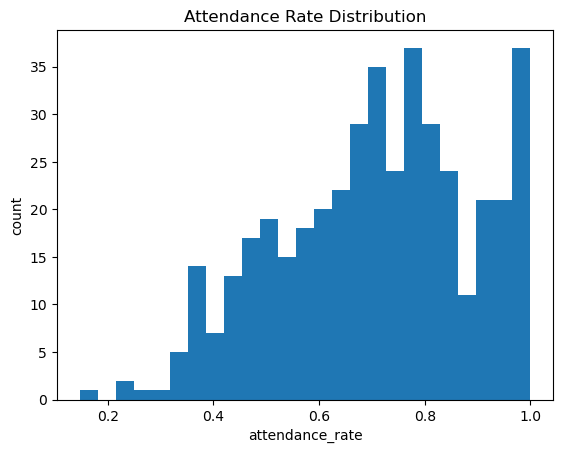

Sellout rate: 0.0496
Mean attendance_rate: 0.7063
Std attendance_rate: 0.1837


In [41]:
plt.figure()
plt.hist(df2["attendance_rate"].dropna(), bins=25)
plt.title("Attendance Rate Distribution")
plt.xlabel("attendance_rate")
plt.ylabel("count")
plt.show()

sellout_rate = (df2["attendance_rate"] >= 0.999).mean()
print("Sellout rate:", round(sellout_rate, 4))
print("Mean attendance_rate:", round(df2["attendance_rate"].mean(), 4))
print("Std attendance_rate:", round(df2["attendance_rate"].std(), 4))


is_weekend_syria
0    0.645088
1    0.812267
Name: attendance_rate, dtype: float64

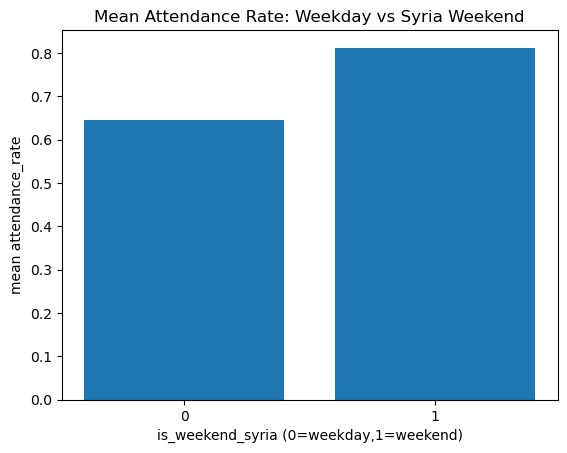

In [42]:
g = df2.groupby("is_weekend_syria")["attendance_rate"].mean()
display(g)

plt.figure()
plt.bar(g.index.astype(str), g.values)
plt.title("Mean Attendance Rate: Weekday vs Syria Weekend")
plt.xlabel("is_weekend_syria (0=weekday,1=weekend)")
plt.ylabel("mean attendance_rate")
plt.show()


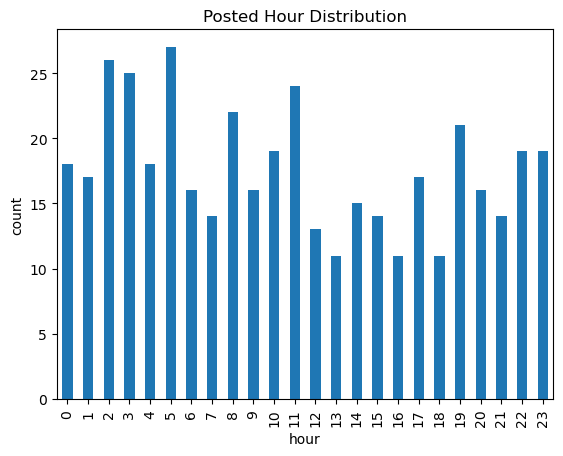

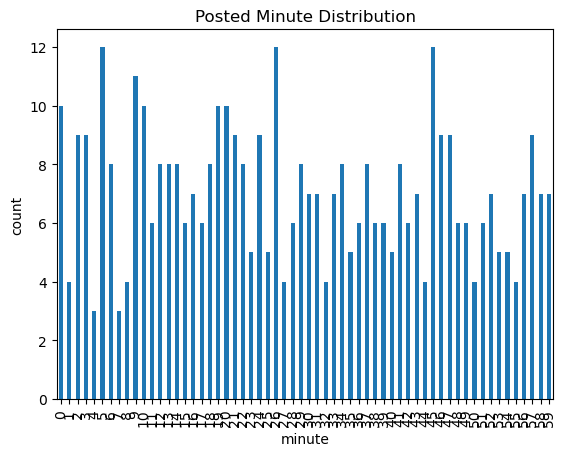

In [43]:
plt.figure()
df2["posted_hour"].value_counts().sort_index().plot(kind="bar")
plt.title("Posted Hour Distribution")
plt.xlabel("hour")
plt.ylabel("count")
plt.show()

plt.figure()
df2["posted_minute"].value_counts().sort_index().plot(kind="bar")
plt.title("Posted Minute Distribution")
plt.xlabel("minute")
plt.ylabel("count")
plt.show()


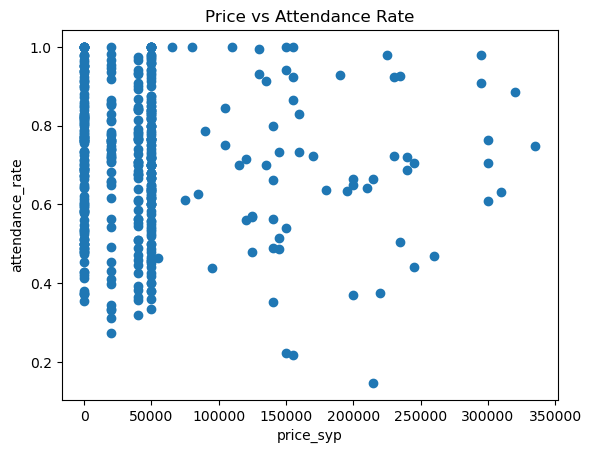

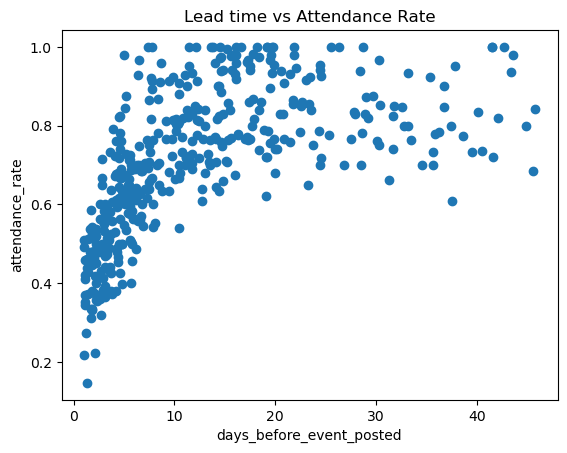

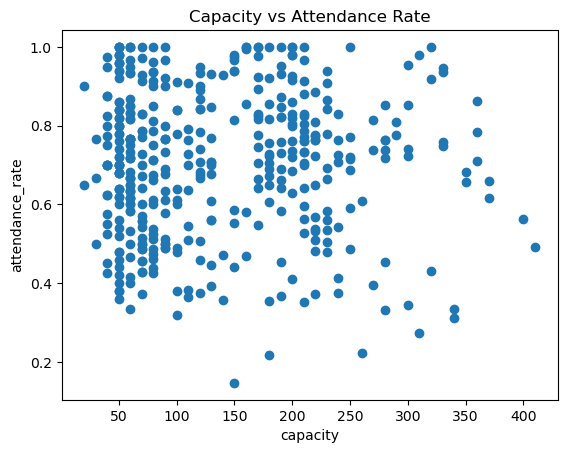

In [44]:
def scatter(x, y, xlabel, ylabel, title):
    plt.figure()
    plt.scatter(x, y)
    plt.xlabel(xlabel); plt.ylabel(ylabel); plt.title(title)
    plt.show()

if "price_syp" in df2.columns:
    scatter(df2["price_syp"], df2["attendance_rate"], "price_syp", "attendance_rate", "Price vs Attendance Rate")

scatter(df2["days_before_event_posted"], df2["attendance_rate"], "days_before_event_posted", "attendance_rate", "Lead time vs Attendance Rate")

scatter(df2["capacity"], df2["attendance_rate"], "capacity", "attendance_rate", "Capacity vs Attendance Rate")
